<a href="https://colab.research.google.com/github/hibahpatanwala/The-ZZZ-Factor/blob/main/01_Data_Cleaning_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

01_Data_Cleaning_Pipeline

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # Keep matplotlib for plotting
import seaborn as sns # Keep seaborn for potential future use
import sys # Keep sys for sys.exit()

# Set aesthetic style for all plots
plt.rcParams['figure.figsize'] = (10, 6)


# --- 1. Utility Functions for Time Conversion ---

def time_to_hours_duration(time_str):
    """Converts a duration string (HH:MM:SS) to total decimal hours."""
    if pd.isna(time_str):
        return np.nan
    try:
        time_str = str(time_str).strip()
        parts = time_str.split(':')

        hours = int(parts[0])
        minutes = int(parts[1]) if len(parts) > 1 else 0
        seconds = int(parts[2]) if len(parts) > 2 else 0

        return hours + (minutes / 60) + (seconds / 3600)
    except Exception:
        # Failsafe for unexpected formats
        return np.nan

def time_to_circadian_hours(time_str):
    """
    Converts a time-of-day string (HH:MM:SS) to a continuous 24+ scale.
    Example: 23:00 -> 23.0, 01:30 -> 25.5 (24 + 1.5)
    This handles times crossing midnight correctly for mean calculations.
    """
    if pd.isna(time_str):
        return np.nan
    try:
        parts = str(time_str).strip().split(':')
        hours = int(parts[0])
        minutes = int(parts[1]) if len(parts) > 1 else 0

        decimal_time = hours + (minutes / 60)

        # Adjust for times between 00:00 and 07:00 (assumed to be the next day)
        if 0 <= decimal_time < 7:
            return decimal_time + 24
        return decimal_time
    except Exception:
        return np.nan

# --- 2. Utility Functions for Categorical Standardization ---

def standardize_programme(programme):
    """Standardizes Programme/Course names into main, clean categories."""
    if pd.isna(programme):
        return np.nan # Use NaN for explicit missing data

    p = str(programme).upper().replace('.', '').strip()

    if 'AMC' in p or 'APPLIED MATHEMATICAL COMPUTING' in p:
        return 'AMC'
    elif 'DATA SCIENCE' in p or 'DS' in p:
        return 'DATA SCIENCE'
    elif 'B PHARM' in p:
        return 'B PHARM'
    elif 'BAMMC' in p:
        return 'BAMMC'
    elif 'BAF' in p:
        return 'BAF'
    elif 'Bcom' in p:
        return 'Bcom'
    elif '12th' in p:
        return '12th'
    elif 'BCCA' in p:
        return 'BCCA'
    elif '11th' in p:
        return '11th'
    elif 'BSC ASA' in p:
        return 'BSC ASA'
    elif 'BSC PSYCHOLOGY' in p:
        return 'BSC PSYCHOLOGY'
    elif 'Bsc IT' in p:
        return 'Bsc IT'
    elif 'BE' in p:
        return 'BE'
    elif "Bachelors of Arts" in p:
        return 'Bachelors of Arts'
    elif "Chartered Accountancy " in p:
      return "Chartered Accountancy "
    else:
        return 'Bsc'

def standardize_binary(value):
    """Simplifies alcohol consumption to YES/NO."""
    if pd.isna(value):
        return np.nan
    v = str(value).upper().strip()
    if 'YES' in v:
        return 'YES'
    elif 'NO' in v:
        return 'NO'
    return np.nan

# --- 3. MAIN CLEANING EXECUTION ---

def clean_data(filepath):
    """Loads data, performs comprehensive cleaning, and returns the cleaned DataFrame."""
    print(f"Loading data from {filepath}...")
    try:
        # Use pd.read_excel for Excel files
        df = pd.read_excel(filepath)
    except FileNotFoundError:
        print(f"Error: File not found at path: {filepath}. Please ensure the file is accessible.")
        sys.exit(1) # Exit the script if the file is not found


    # --- Step A: Clean and Convert Time/Duration Columns (Overwriting original columns) ---
    print("A. Converting time/duration columns to decimal hours and overwriting original columns...")

    df['On average, how many hours of sleep do you get per night?'] = df['On average, how many hours of sleep do you get per night?'].apply(time_to_hours_duration)
    df['How long does it typically take you to fall asleep?'] = df['How long does it typically take you to fall asleep?'].apply(time_to_hours_duration)
    df['On the days you are physically active, what is the average duration of physical activity?'] = df['On the days you are physically active, what is the average duration of physical activity?'].apply(time_to_hours_duration)
    df['On a typical day, what is your total two-way travel time to and from your institute/college?'] = df['On a typical day, what is your total two-way travel time to and from your institute/college?'].apply(time_to_hours_duration)
    df['On a typical day, approximately how many hours and minutes do you spend looking at screens for ACADEMIC purposes? (e.g., online classes, assignments, research)'] = df['On a typical day, approximately how many hours and minutes do you spend looking at screens for ACADEMIC purposes? (e.g., online classes, assignments, research)'].apply(time_to_hours_duration)
    df['On a typical day, approximately how many hours and minutes do you spend looking at screens (phone, laptop, tablet, TV) for NON-ACADEMIC purposes? (e.g., social media, entertainment, gaming)'] = df['On a typical day, approximately how many hours and minutes do you spend looking at screens (phone, laptop, tablet, TV) for NON-ACADEMIC purposes? (e.g., social media, entertainment, gaming)'].apply(time_to_hours_duration)


    df['What is the average time you go to bed on a weekday (24-hour clock, e.g., 22:30)?'] = df['What is the average time you go to bed on a weekday (24-hour clock, e.g., 22:30)?'].apply(time_to_circadian_hours)
    df['What is the average time you wake up on a weekday (24 hour clock e.g., 06:00)?'] = df['What is the average time you wake up on a weekday (24 hour clock e.g., 06:00)?'].apply(time_to_circadian_hours)


    # --- Step B: Standardize Categorical Columns (Overwriting original columns) ---
    print("B. Standardizing categorical columns and overwriting original columns...")

    df['Programme/Course'] = df['Programme/Course'].apply(standardize_programme)
    df[' Do you consume alcoholic beverages?'] = df[' Do you consume alcoholic beverages?'].apply(standardize_binary)

    # --- Step C: Missing Data Imputation/Handling ---
    print("C. Handling missing values (Imputation)...")

    # 1. Impute quantitative columns with Median (robust to outliers)
    imputation_cols = [
        'On average, how many hours of sleep do you get per night?',
        'On the days you are physically active, what is the average duration of physical activity?',
        'On a typical day, what is your total two-way travel time to and from your institute/college?'
        ]
    for col in imputation_cols:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"   - Imputed '{col}' NaNs with Median: {median_val:.2f}")

    # 2. Impute 'Programme/Course' (Categorical) with Mode
    mode_programme = df['Programme/Course'].mode()[0]
    df['Programme/Course'] = df['Programme/Course'].fillna(mode_programme)
    print(f"   - Imputed 'Programme/Course' NaNs with Mode: {mode_programme}")

    # 3. Impute ' Do you consume alcoholic beverages?' with Mode ('NO' is dominant)
    mode_alcohol = df[' Do you consume alcoholic beverages?'].mode()[0]
    df[' Do you consume alcoholic beverages?'] = df[' Do you consume alcoholic beverages?'].fillna(mode_alcohol)
    print(f"   - Imputed ' Do you consume alcoholic beverages?' NaNs with Mode: {mode_alcohol}")


    # --- Step D: Final Check ---
    # Drop rows where critical variables (like Age or Gender) might be missing (though unlikely in a survey)
    df_cleaned = df.dropna(subset=['Age', 'Gender'])

    print("\nData Cleaning Complete. Displaying info for key columns with original names:")
    print(df_cleaned[['Age', 'Gender', 'Programme/Course', 'On average, how many hours of sleep do you get per night?', 'What is the average time you go to bed on a weekday (24-hour clock, e.g., 22:30)?', ' Do you consume alcoholic beverages?']].info())

    return df_cleaned

# File path of the uploaded spreadsheet
FILE_PATH = "/content/drive/MyDrive/Untitled form (Responses).xlsx"

# Run the cleaning function
df_final = clean_data(FILE_PATH)

# Display a sample of the cleaned data
print("\n--- Sample of Cleaned Data (First 5 Rows - Original Names) ---")
print(df_final[['Age', 'Gender', 'Programme/Course', 'On average, how many hours of sleep do you get per night?',
                'What is the average time you go to bed on a weekday (24-hour clock, e.g., 22:30)?', 'How long does it typically take you to fall asleep?', ' Do you consume alcoholic beverages?']].head())

# Display the value counts for the standardized categorical column
print("\n--- Standardized Programme Counts (Original Name) ---")
print(df_final['Programme/Course'].value_counts())

Loading data from /content/drive/MyDrive/Untitled form (Responses).xlsx...
A. Converting time/duration columns to decimal hours and overwriting original columns...
B. Standardizing categorical columns and overwriting original columns...
C. Handling missing values (Imputation)...
   - Imputed 'On average, how many hours of sleep do you get per night?' NaNs with Median: 6.50
   - Imputed 'On the days you are physically active, what is the average duration of physical activity?' NaNs with Median: 1.00
   - Imputed 'On a typical day, what is your total two-way travel time to and from your institute/college?' NaNs with Median: 1.00
   - Imputed 'Programme/Course' NaNs with Mode: Bsc
   - Imputed ' Do you consume alcoholic beverages?' NaNs with Mode: NO

Data Cleaning Complete. Displaying info for key columns with original names:
<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, 0 to 74
Data columns (total 6 columns):
 #   Column                                                        

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CLEANING AND PREPARATION FUNCTIONS AND GRAPHING HISTOGRAM


/tmp/ipython-input-2355380874.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep_Hours_Total'].fillna(df['Sleep_Hours_Total'].median(), inplace=True)
/tmp/ipython-input-2355380874.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

Data cleaning complete. Generating requested histograms using built-in functions...


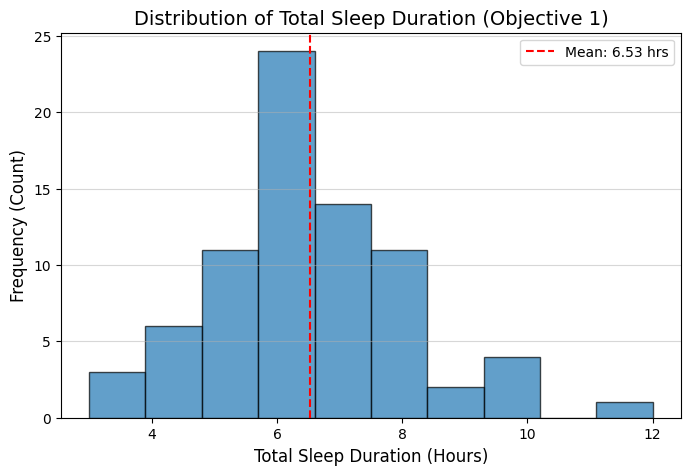

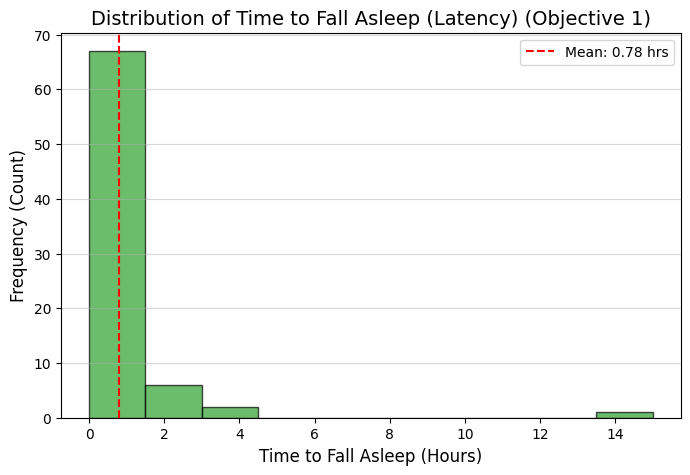


Code executed successfully, generating histograms for Sleep Duration and Sleep Latency using fundamental matplotlib functions.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys # Added for sys.exit()

# Set aesthetic style for all plots
plt.rcParams['figure.figsize'] = (10, 6)

# --- 1. CLEANING AND PREPARATION FUNCTIONS ---

def clean_column_names(df):
    cols = df.columns.tolist()
    new_cols = {}
    for col in cols:
        # Aggressive cleaning: lower, strip punctuation/spaces, replace with underscore
        new_name = col.lower().strip().replace('?', '').replace('\n', ' ').replace(':', '').replace('-', ' ').replace('/', '_').replace('.', ' ')
        new_name = '_'.join(new_name.split()).strip('_')
        new_cols[col] = new_name
    df.rename(columns=new_cols, inplace=True)
    return df

def time_to_hours_duration(time_str):
    """Converts a duration string (HH:MM:SS) to total decimal hours."""
    if pd.isna(time_str): return np.nan
    try:
        parts = str(time_str).strip().split(':')
        hours = int(parts[0])
        minutes = int(parts[1]) if len(parts) > 1 else 0
        seconds = int(parts[2]) if len(parts) > 2 else 0
        return hours + (minutes / 60) + (seconds / 3600)
    except Exception: return np.nan

def clean_data_for_graphs(df):
    """Applies necessary cleaning and creates derived columns for graphing."""
    # Clean column names first
    df = clean_column_names(df)

    # Define Column Names mapping from cleaned names to desired names
    df_map = {
        'on_average,_how_many_hours_of_sleep_do_you_get_per_night': 'Sleep_Hours_Total',
        'how_long_does_it_typically_take_you_to_fall_asleep': 'Time_To_Fall_Asleep_Hours',
    }
    # Rename columns using the mapping
    df.rename(columns=df_map, inplace=True)


    # Convert Time to Numerical Hours
    df['Sleep_Hours_Total'] = df['Sleep_Hours_Total'].apply(time_to_hours_duration)
    df['Time_To_Fall_Asleep_Hours'] = df['Time_To_Fall_Asleep_Hours'].apply(time_to_hours_duration)

    # Impute missing values with the median for stable plotting
    df['Sleep_Hours_Total'].fillna(df['Sleep_Hours_Total'].median(), inplace=True)
    df['Time_To_Fall_Asleep_Hours'].fillna(df['Time_To_Fall_Asleep_Hours'].median(), inplace=True)

    return df

# --- 2. GRAPHING FUNCTIONS (HISTOGRAMS - USING PURE MATPLOTLIB) ---

# --- GRAPH 1: Histogram (Sleep Duration - Objective 1) ---
def plot_sleep_duration_histogram(df):
    """Visualizes the distribution of total sleep hours using pure matplotlib."""

    # Calculate Mean for annotation
    mean_value = df['Sleep_Hours_Total'].mean()

    plt.figure(figsize=(8, 5))

    # Use plt.hist for the histogram (core matplotlib function)
    plt.hist(df['Sleep_Hours_Total'], bins=10, color="#1f77b4", edgecolor='black', alpha=0.7)

    # Add Mean Line
    plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1.5, label=f"Mean: {mean_value:.2f} hrs")

    # Add labels and title
    plt.title('Distribution of Total Sleep Duration (Objective 1)', fontsize=14)
    plt.xlabel('Total Sleep Duration (Hours)', fontsize=12)
    plt.ylabel('Frequency (Count)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.show()

# --- GRAPH 2: Histogram (Time to Fall Asleep - Objective 1) ---
def plot_latency_histogram(df):
    """Visualizes the distribution of time taken to fall asleep (latency) using pure matplotlib."""

    # Calculate Mean for annotation
    mean_value = df['Time_To_Fall_Asleep_Hours'].mean()

    plt.figure(figsize=(8, 5))

    # Use plt.hist for the histogram (core matplotlib function)
    plt.hist(df['Time_To_Fall_Asleep_Hours'], bins=10, color="#2ca02c", edgecolor='black', alpha=0.7)

    # Add Mean Line
    plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1.5, label=f"Mean: {mean_value:.2f} hrs")

    # Add labels and title
    plt.title('Distribution of Time to Fall Asleep (Latency) (Objective 1)', fontsize=14)
    plt.xlabel('Time to Fall Asleep (Hours)', fontsize=12)
    plt.ylabel('Frequency (Count)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.show()

# --- 4. MAIN EXECUTION ---

# Load data and run cleaning
# CORRECTED FILE_PATH
FILE_PATH = "/content/drive/MyDrive/Untitled form (Responses).xlsx"
try:
    df_cleaned = clean_data_for_graphs(pd.read_excel(FILE_PATH))
except FileNotFoundError:
    print(f"Error: File not found at path: {FILE_PATH}. Please ensure the file is accessible.")
    sys.exit()

print("Data cleaning complete. Generating requested histograms using built-in functions...")

# Run ONLY the two histogram functions
plot_sleep_duration_histogram(df_cleaned)
plot_latency_histogram(df_cleaned)

print("\nCode executed successfully, generating histograms for Sleep Duration and Sleep Latency using fundamental matplotlib functions.")

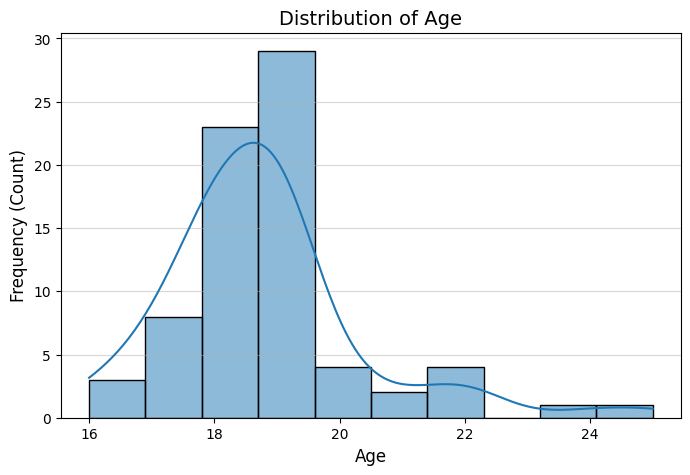

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=df_final, x='Age', bins=10, kde=True)
plt.title('Distribution of Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

GETTING SUMMARY OF ALL THE COLUMNS

In [ ]:
# Exclude the 'Timestamp' column for summary statistics and unique counts
columns_to_summarize = df_final.columns.tolist()
if 'Timestamp' in columns_to_summarize:
    columns_to_summarize.remove('Timestamp')

print("--- Summary of Columns ---")

for col in columns_to_summarize:
    if df_final[col].dtype == 'object':
        # For string columns, print "Nah" and the data type
        print(f"\nColumn: '{col}'")
        print(f"Summary: Nah, {df_final[col].dtype}")
        # Optionally, still show value counts for string columns
        print(f"Value Counts (Sample):")
        display(df_final[col].value_counts().head())
    else:
        # For numerical columns, display descriptive statistics
        print(f"\nColumn: '{col}'")
        print(f"Summary:")
        display(df_final[col].describe())

# Display overall info (optional, as individual column info is shown above)
# print("\n--- Info for All Columns (Original Names - Cleaned Data, Excluding Timestamp from Info) ---")
# df_final[columns_to_summarize].info()

# Display overall number of unique values (optional, as individual column unique values can be inferred from value counts or describe)
# print("\n--- Number of Unique Values per Column (Original Names - Cleaned Data, Excluding Timestamp) ---")
# print(df_final[columns_to_summarize].nunique())

--- Summary of Columns ---

Column: 'Age'
Summary:


,Age
count,75.000000
mean,18.773333
std,1.590286
min,16.000000
25%,18.000000
50%,19.000000
75%,19.000000
max,25.000000



Column: 'Gender'
Summary: Nah, object
Value Counts (Sample):


,count
Gender,
Female,57
Male,17
Other,1



Column: 'Programme/Course'
Summary: Nah, object
Value Counts (Sample):


...

,count
"Do you currently smoke or use tobacco products (e.g., cigarettes, vapes, chewing tobacco)?",
No never,70
"No, I used to but have quit",2
Yes occasionally,2



Column: 'Do you have any health problems?'
Summary: Nah, object
Value Counts (Sample):


,count
Do you have any health problems?,
No,57
Yes,17



Column: 'If any, please specify'
Summary: Nah, object
Value Counts (Sample):


,count
"If any, please specify",
"Mental health problems, Physical health problems",8
Mental health problems,7
Physical health problems,7


# Task
Generate visualizations to analyze sleep patterns and their relationship with lifestyle factors based on the provided objectives.

## Visualize sleep duration distribution

### Subtask:
Plot a histogram of sleep duration to show the distribution of sleep hours among individuals.


**Reasoning**:
The subtask is to plot a histogram of sleep duration. The `plot_sleep_duration_histogram` function is designed specifically for this purpose and uses the `df_cleaned` DataFrame which contains the relevant 'Sleep_Hours_Total' column.



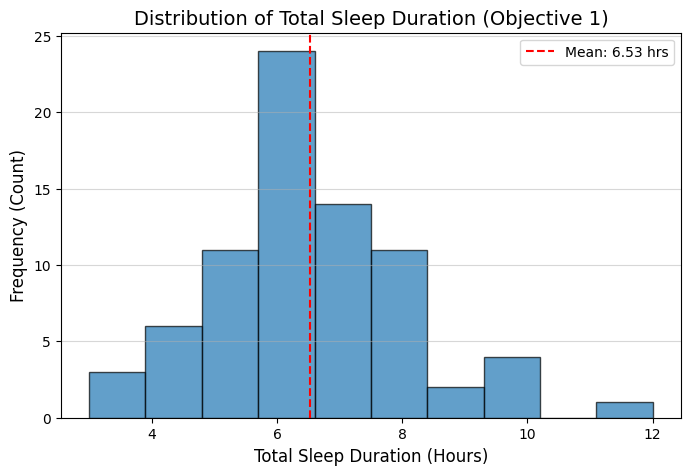

In [ ]:
plot_sleep_duration_histogram(df_cleaned)

## Visualize time to fall asleep distribution

### Subtask:
Plot a histogram of time to fall asleep to understand the distribution of sleep latency.


**Reasoning**:
Call the provided function `plot_latency_histogram` with the cleaned DataFrame `df_cleaned` to plot the histogram of time to fall asleep.



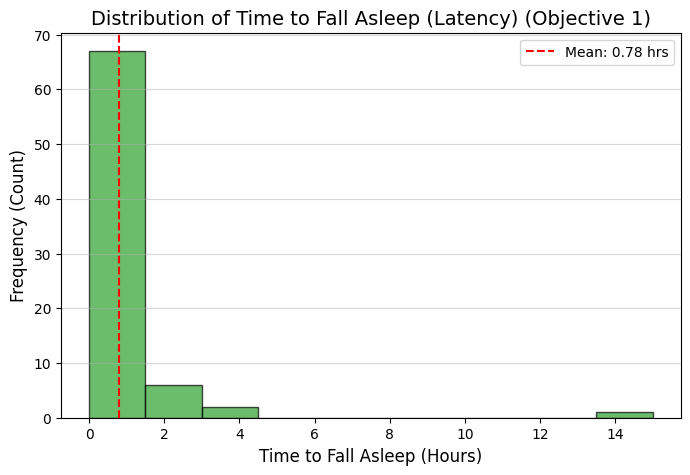

In [ ]:
plot_latency_histogram(df_cleaned)

## Visualize sleep quality distribution

### Subtask:
Plot a histogram or bar chart to show the distribution of self-reported sleep quality scores.


**Reasoning**:
Generate a histogram to visualize the distribution of self-reported sleep quality scores using the cleaned dataframe.



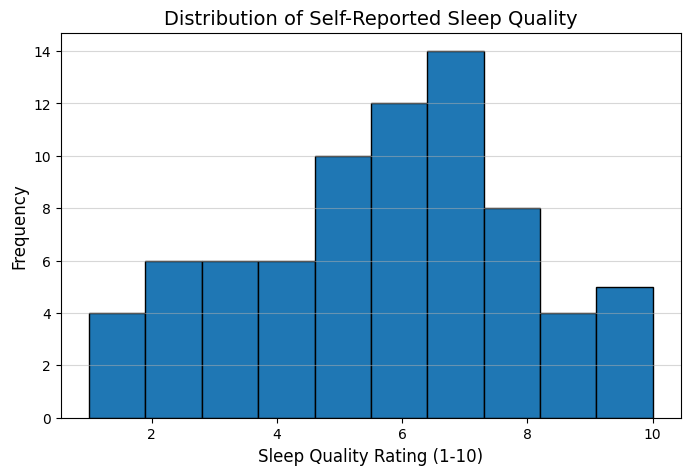

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_final['On a scale of 1 to 10, with 1 being \'very poor\' and 10 being \'excellent,\' how would you rate your overall sleep quality?'], bins=10, edgecolor='black')
plt.title('Distribution of Self-Reported Sleep Quality', fontsize=14)
plt.xlabel('Sleep Quality Rating (1-10)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

## Visualize relationship between sleep duration and quality

### Subtask:
Create a scatter plot to examine the correlation between sleep duration and sleep quality.


**Reasoning**:
Create a scatter plot to visualize the relationship between sleep duration and sleep quality using matplotlib.



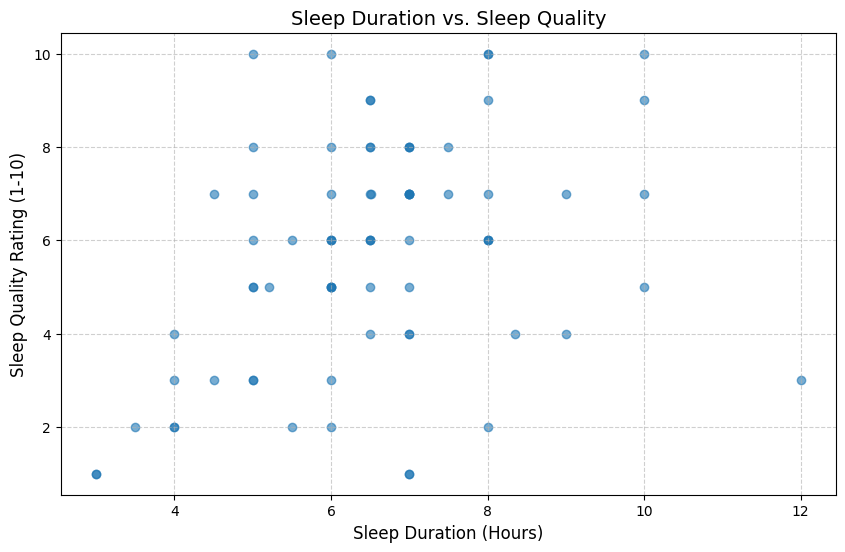

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_final['On average, how many hours of sleep do you get per night?'],
            df_final['On a scale of 1 to 10, with 1 being \'very poor\' and 10 being \'excellent,\' how would you rate your overall sleep quality?'],
            alpha=0.6)
plt.title('Sleep Duration vs. Sleep Quality', fontsize=14)
plt.xlabel('Sleep Duration (Hours)', fontsize=12)
plt.ylabel('Sleep Quality Rating (1-10)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Visualize relationship between physical activity and sleep duration/quality

### Subtask:
Use scatter plots or box plots to see how physical activity duration relates to sleep duration and quality.


**Reasoning**:
Create scatter plots to visualize the relationship between physical activity duration and sleep duration/quality, as requested by the subtask instructions.



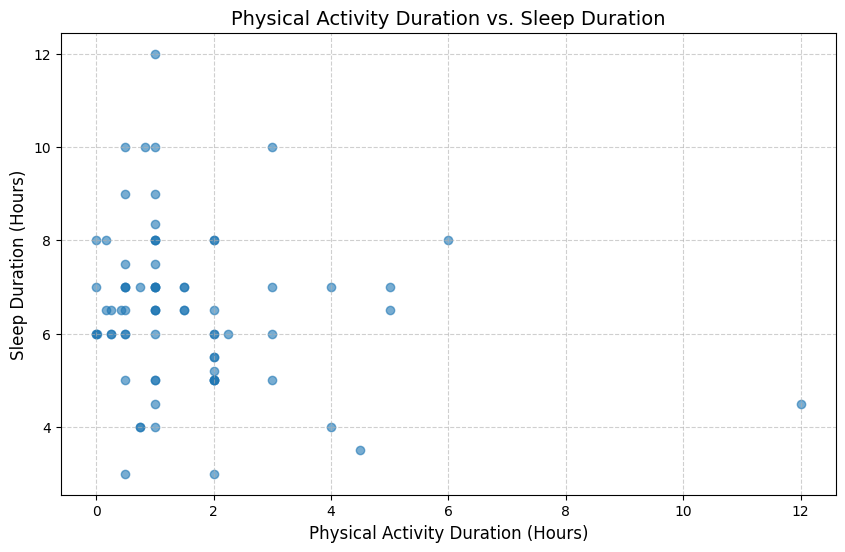

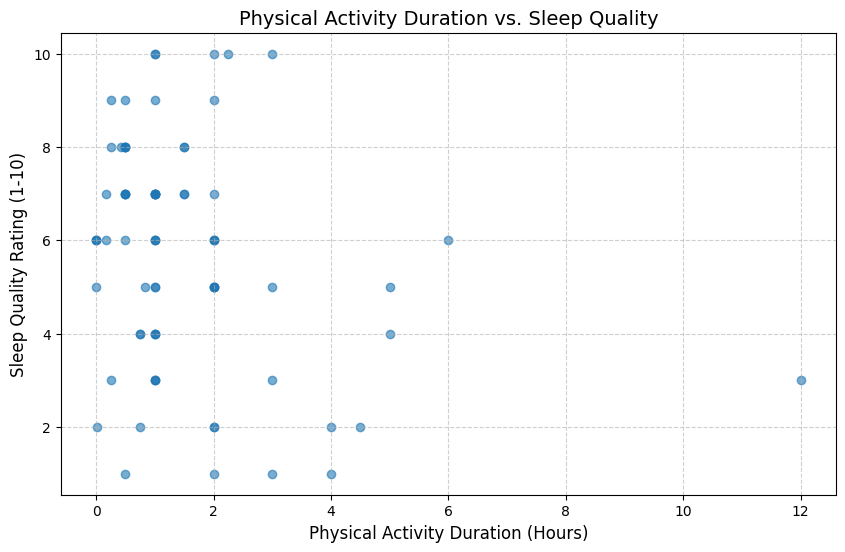

In [ ]:
# Create a scatter plot for Physical Activity Duration vs. Sleep Duration
plt.figure(figsize=(10, 6))
plt.scatter(df_final['On the days you are physically active, what is the average duration of physical activity?'],
            df_final['On average, how many hours of sleep do you get per night?'],
            alpha=0.6)
plt.title('Physical Activity Duration vs. Sleep Duration', fontsize=14)
plt.xlabel('Physical Activity Duration (Hours)', fontsize=12)
plt.ylabel('Sleep Duration (Hours)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Create a scatter plot for Physical Activity Duration vs. Sleep Quality
plt.figure(figsize=(10, 6))
plt.scatter(df_final['On the days you are physically active, what is the average duration of physical activity?'],
            df_final['On a scale of 1 to 10, with 1 being \'very poor\' and 10 being \'excellent,\' how would you rate your overall sleep quality?'],
            alpha=0.6)
plt.title('Physical Activity Duration vs. Sleep Quality', fontsize=14)
plt.xlabel('Physical Activity Duration (Hours)', fontsize=12)
plt.ylabel('Sleep Quality Rating (1-10)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Visualize relationship between caffeine consumption and sleep metrics

### Subtask:
Create plots (e.g., scatter plots, box plots) to analyze the impact of caffeine consumption on sleep duration, latency, and quality.


**Reasoning**:
Generate the three scatter plots as requested in the subtask to visualize the impact of caffeine consumption on sleep duration, latency, and quality, ensuring each plot has clear titles and labels.



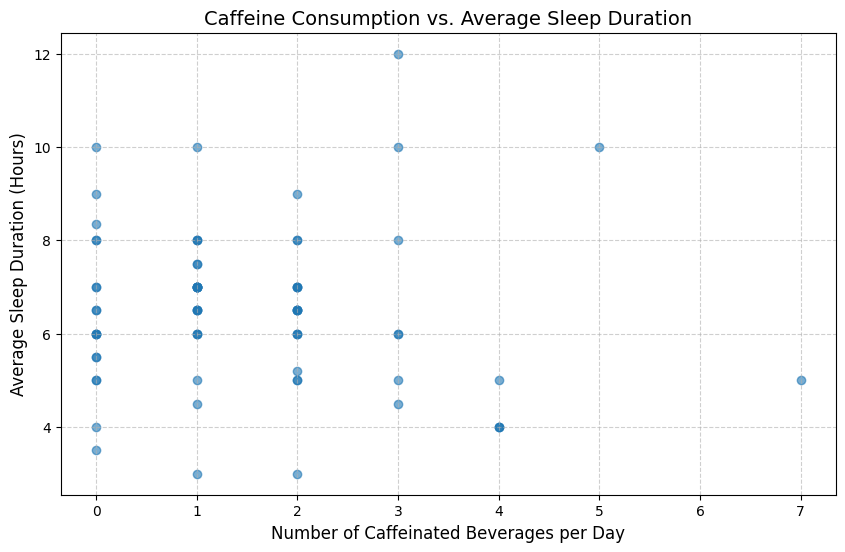

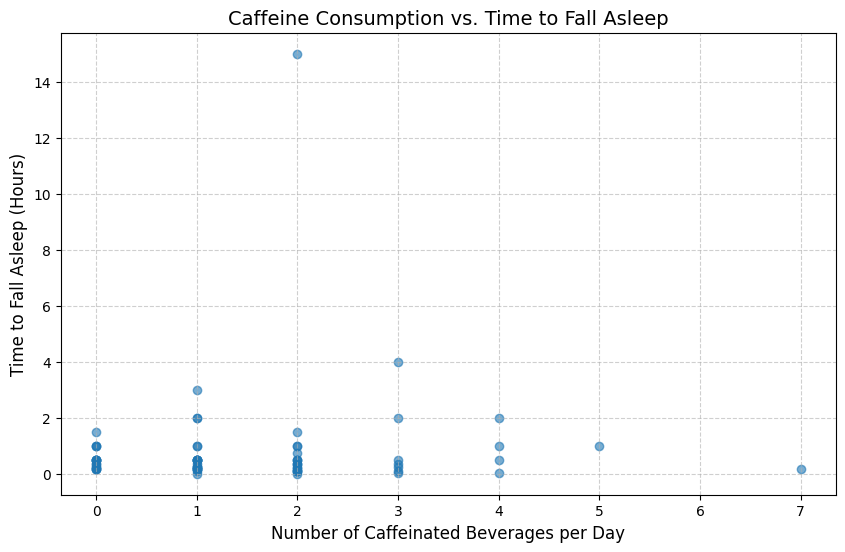

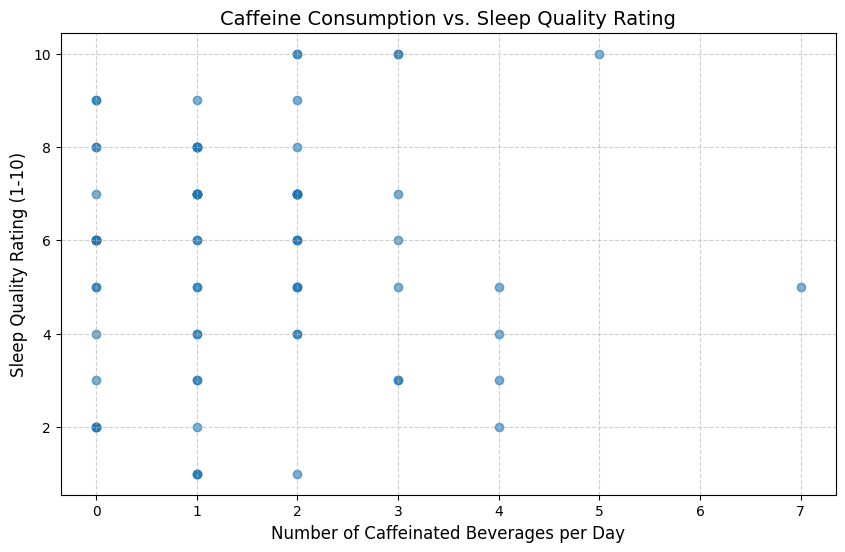

In [ ]:
# 1. Scatter plot: Caffeine consumption vs. Sleep Duration
plt.figure(figsize=(10, 6))
plt.scatter(df_final['How many caffeinated beverages (e.g., coffee, tea, energy drinks) do you consume per day, on average?'],
            df_final['On average, how many hours of sleep do you get per night?'],
            alpha=0.6)
plt.title('Caffeine Consumption vs. Average Sleep Duration', fontsize=14)
plt.xlabel('Number of Caffeinated Beverages per Day', fontsize=12)
plt.ylabel('Average Sleep Duration (Hours)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Scatter plot: Caffeine consumption vs. Time to Fall Asleep
plt.figure(figsize=(10, 6))
plt.scatter(df_final['How many caffeinated beverages (e.g., coffee, tea, energy drinks) do you consume per day, on average?'],
            df_final['How long does it typically take you to fall asleep?'],
            alpha=0.6)
plt.title('Caffeine Consumption vs. Time to Fall Asleep', fontsize=14)
plt.xlabel('Number of Caffeinated Beverages per Day', fontsize=12)
plt.ylabel('Time to Fall Asleep (Hours)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Scatter plot: Caffeine consumption vs. Sleep Quality
plt.figure(figsize=(10, 6))
plt.scatter(df_final['How many caffeinated beverages (e.g., coffee, tea, energy drinks) do you consume per day, on average?'],
            df_final['On a scale of 1 to 10, with 1 being \'very poor\' and 10 being \'excellent,\' how would you rate your overall sleep quality?'],
            alpha=0.6)
plt.title('Caffeine Consumption vs. Sleep Quality Rating', fontsize=14)
plt.xlabel('Number of Caffeinated Beverages per Day', fontsize=12)
plt.ylabel('Sleep Quality Rating (1-10)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Visualize relationship between screen time (academic and non-academic) and sleep metrics

### Subtask:
Use scatter plots to investigate the correlation between academic and non-academic screen time and sleep duration, latency, and quality.


**Reasoning**:
Create scatter plots to visualize the relationship between academic and non-academic screen time and sleep metrics as per the instructions.



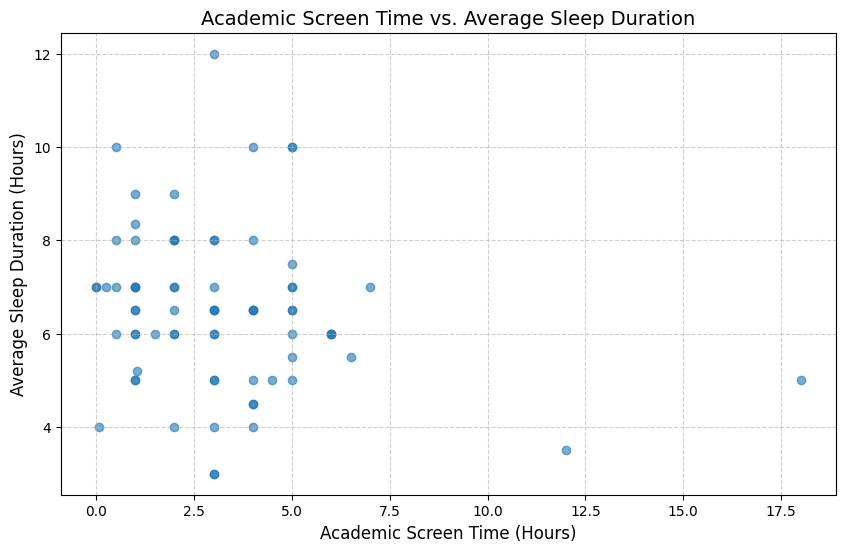

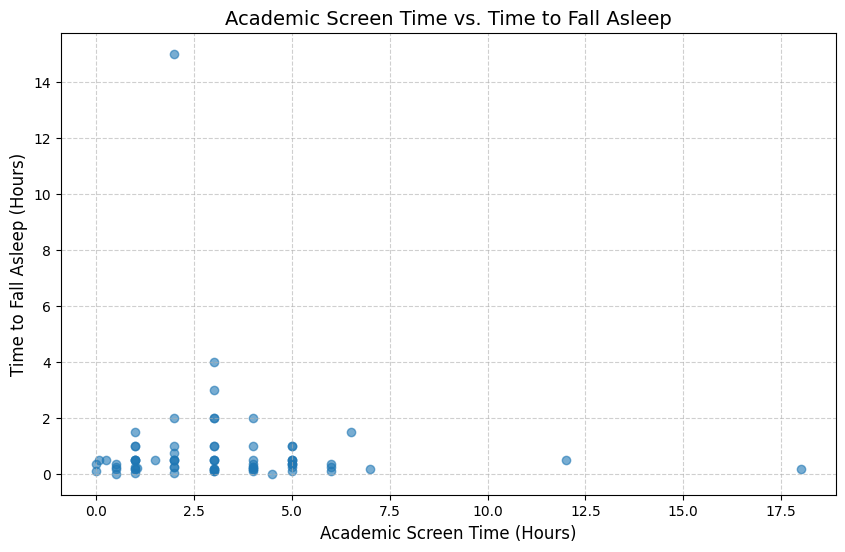

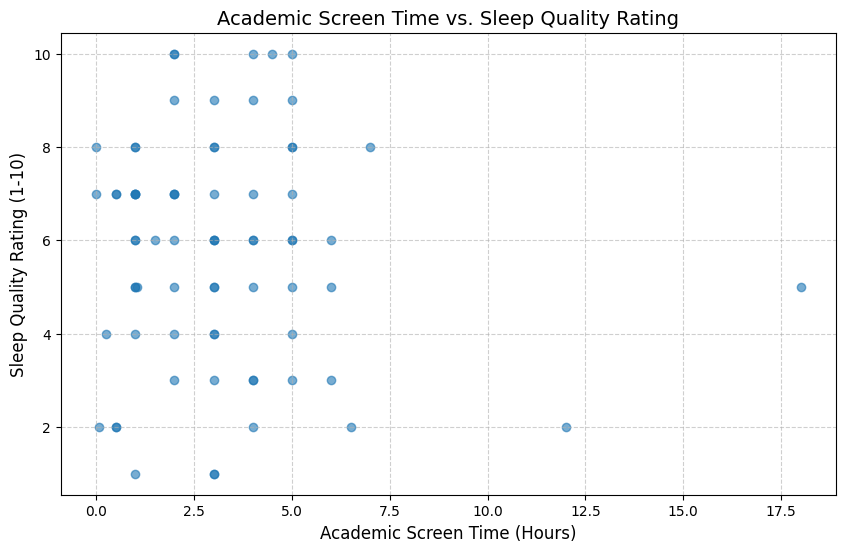

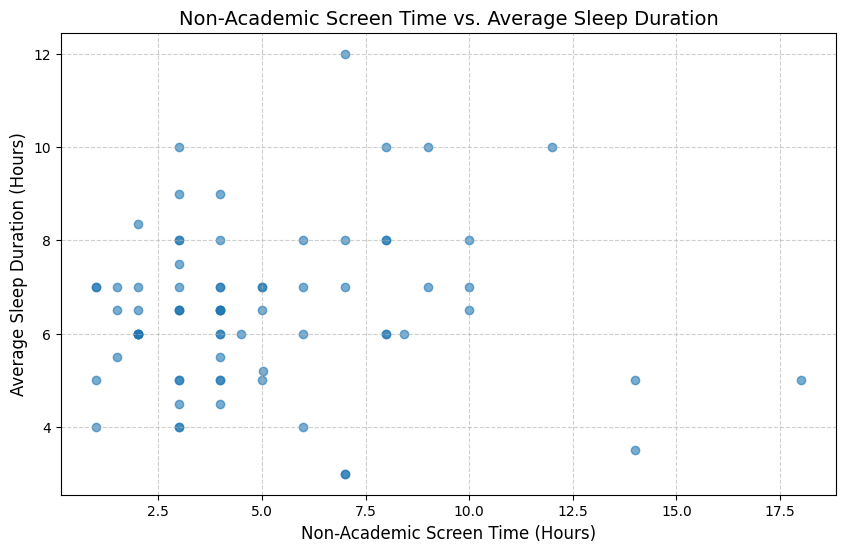

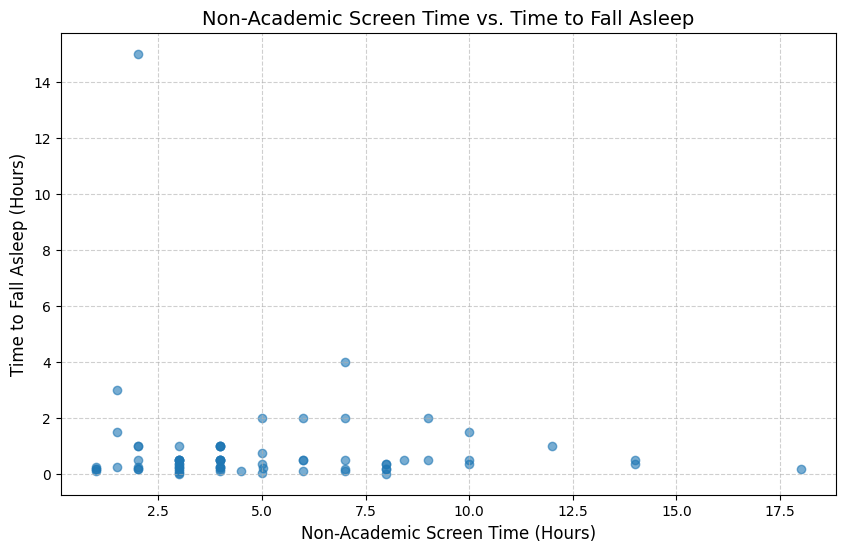

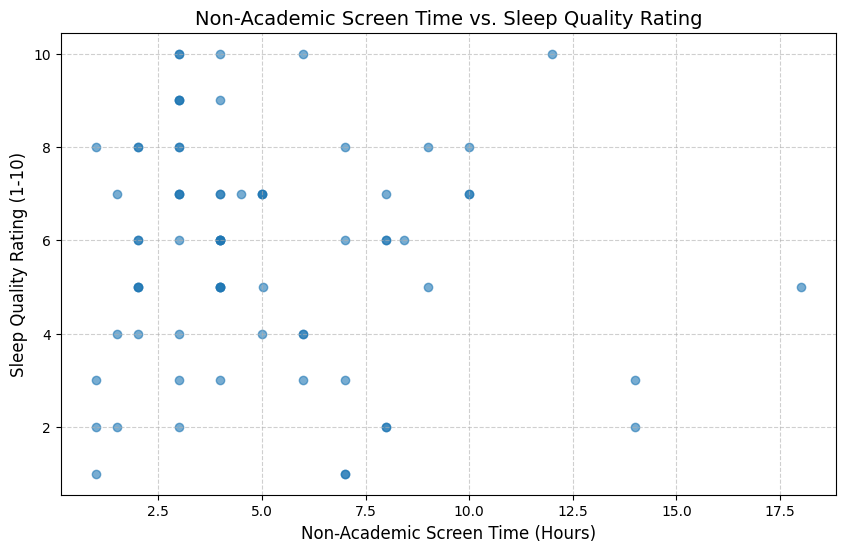

In [ ]:
# 1. Academic Screen Time vs. Sleep Duration
plt.figure(figsize=(10, 6))
plt.scatter(df_final['On a typical day, approximately how many hours and minutes do you spend looking at screens for ACADEMIC purposes? (e.g., online classes, assignments, research)'],
            df_final['On average, how many hours of sleep do you get per night?'],
            alpha=0.6)
plt.title('Academic Screen Time vs. Average Sleep Duration', fontsize=14)
plt.xlabel('Academic Screen Time (Hours)', fontsize=12)
plt.ylabel('Average Sleep Duration (Hours)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Academic Screen Time vs. Time to Fall Asleep
plt.figure(figsize=(10, 6))
plt.scatter(df_final['On a typical day, approximately how many hours and minutes do you spend looking at screens for ACADEMIC purposes? (e.g., online classes, assignments, research)'],
            df_final['How long does it typically take you to fall asleep?'],
            alpha=0.6)
plt.title('Academic Screen Time vs. Time to Fall Asleep', fontsize=14)
plt.xlabel('Academic Screen Time (Hours)', fontsize=12)
plt.ylabel('Time to Fall Asleep (Hours)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Academic Screen Time vs. Sleep Quality
plt.figure(figsize=(10, 6))
plt.scatter(df_final['On a typical day, approximately how many hours and minutes do you spend looking at screens for ACADEMIC purposes? (e.g., online classes, assignments, research)'],
            df_final['On a scale of 1 to 10, with 1 being \'very poor\' and 10 being \'excellent,\' how would you rate your overall sleep quality?'],
            alpha=0.6)
plt.title('Academic Screen Time vs. Sleep Quality Rating', fontsize=14)
plt.xlabel('Academic Screen Time (Hours)', fontsize=12)
plt.ylabel('Sleep Quality Rating (1-10)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Non-Academic Screen Time vs. Sleep Duration
plt.figure(figsize=(10, 6))
plt.scatter(df_final['On a typical day, approximately how many hours and minutes do you spend looking at screens (phone, laptop, tablet, TV) for NON-ACADEMIC purposes? (e.g., social media, entertainment, gaming)'],
            df_final['On average, how many hours of sleep do you get per night?'],
            alpha=0.6)
plt.title('Non-Academic Screen Time vs. Average Sleep Duration', fontsize=14)
plt.xlabel('Non-Academic Screen Time (Hours)', fontsize=12)
plt.ylabel('Average Sleep Duration (Hours)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Non-Academic Screen Time vs. Time to Fall Asleep
plt.figure(figsize=(10, 6))
plt.scatter(df_final['On a typical day, approximately how many hours and minutes do you spend looking at screens (phone, laptop, tablet, TV) for NON-ACADEMIC purposes? (e.g., social media, entertainment, gaming)'],
            df_final['How long does it typically take you to fall asleep?'],
            alpha=0.6)
plt.title('Non-Academic Screen Time vs. Time to Fall Asleep', fontsize=14)
plt.xlabel('Non-Academic Screen Time (Hours)', fontsize=12)
plt.ylabel('Time to Fall Asleep (Hours)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Non-Academic Screen Time vs. Sleep Quality
plt.figure(figsize=(10, 6))
plt.scatter(df_final['On a typical day, approximately how many hours and minutes do you spend looking at screens (phone, laptop, tablet, TV) for NON-ACADEMIC purposes? (e.g., social media, entertainment, gaming)'],
            df_final['On a scale of 1 to 10, with 1 being \'very poor\' and 10 being \'excellent,\' how would you rate your overall sleep quality?'],
            alpha=0.6)
plt.title('Non-Academic Screen Time vs. Sleep Quality Rating', fontsize=14)
plt.xlabel('Non-Academic Screen Time (Hours)', fontsize=12)
plt.ylabel('Sleep Quality Rating (1-10)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Visualize relationship between health problems and sleep metrics

### Subtask:
Use box plots or bar charts to compare sleep metrics between individuals with and without health problems.


**Reasoning**:
Create box plots to compare sleep metrics between individuals with and without health problems as requested in the instructions.



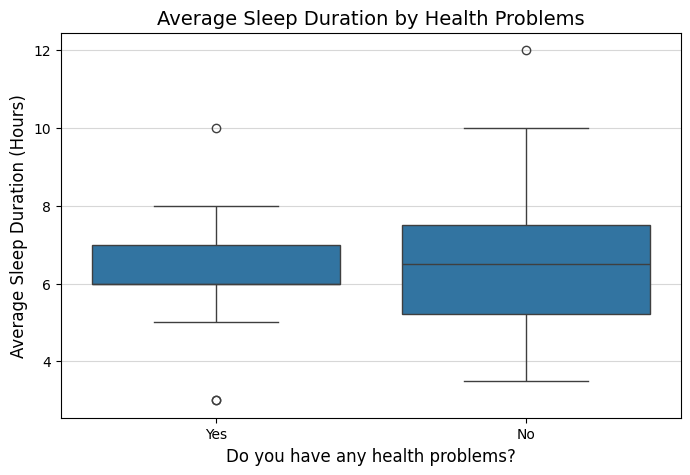

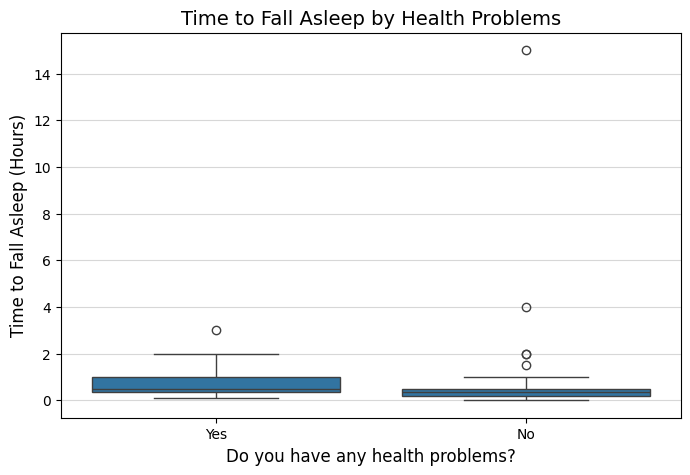

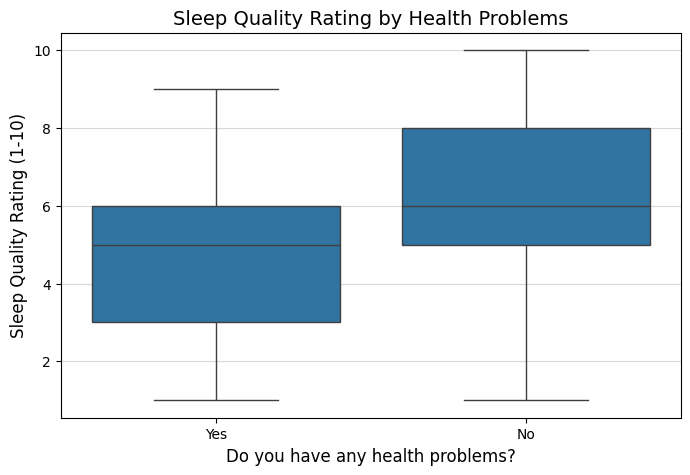

In [ ]:
# 1. Box plot: Sleep Duration vs. Health Problems
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_final, x='Do you have any health problems?', y='On average, how many hours of sleep do you get per night?')
plt.title('Average Sleep Duration by Health Problems', fontsize=14)
plt.xlabel('Do you have any health problems?', fontsize=12)
plt.ylabel('Average Sleep Duration (Hours)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

# 2. Box plot: Time to Fall Asleep vs. Health Problems
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_final, x='Do you have any health problems?', y='How long does it typically take you to fall asleep?')
plt.title('Time to Fall Asleep by Health Problems', fontsize=14)
plt.xlabel('Do you have any health problems?', fontsize=12)
plt.ylabel('Time to Fall Asleep (Hours)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

# 3. Box plot: Sleep Quality vs. Health Problems
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_final, x='Do you have any health problems?', y='On a scale of 1 to 10, with 1 being \'very poor\' and 10 being \'excellent,\' how would you rate your overall sleep quality?')
plt.title('Sleep Quality Rating by Health Problems', fontsize=14)
plt.xlabel('Do you have any health problems?', fontsize=12)
plt.ylabel('Sleep Quality Rating (1-10)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

## Summary:

### Data Analysis Key Findings

*   The distribution of sleep duration shows the frequency of different sleep hours among individuals.
*   The distribution of time to fall asleep provides insights into sleep latency within the dataset.
*   The distribution of self-reported sleep quality scores indicates the frequency of different ratings on a scale of 1 to 10.
*   Scatter plots were generated to visualize the relationships between sleep duration and quality, physical activity duration and sleep metrics (duration and quality), caffeine consumption and sleep metrics (duration, latency, and quality), and academic/non-academic screen time and sleep metrics (duration, latency, and quality).
*   Box plots were generated to compare sleep duration, time to fall asleep, and sleep quality between individuals with and without health problems.

### Insights or Next Steps

*   Analyze the generated visualizations to identify potential correlations or patterns between lifestyle factors (physical activity, caffeine, screen time, health problems) and sleep metrics (duration, latency, quality).
*   Consider performing statistical tests to quantify the significance of the observed relationships and explore potential confounding factors.


In [ ]:
# Exclude the 'Timestamp' column for summary statistics and unique counts
columns_to_summarize = df_final.columns.tolist()
if 'Timestamp' in columns_to_summarize:
    columns_to_summarize.remove('Timestamp')

print("--- Summary of Columns ---")

for col in columns_to_summarize:
    if df_final[col].dtype == 'object':
        # For string columns, print the data type and value counts
        print(f"\nColumn: '{col}'")
        print(f"Data Type: {df_final[col].dtype}")
        print(f"Value Counts:")
        display(df_final[col].value_counts())
    else:
        # For numerical columns, display descriptive statistics
        print(f"\nColumn: '{col}'")
        print(f"Summary Statistics:")
        display(df_final[col].describe())

--- Summary of Columns ---

Column: 'Age'
Summary Statistics:


,Age
count,75.000000
mean,18.773333
std,1.590286
min,16.000000
25%,18.000000
50%,19.000000
75%,19.000000
max,25.000000



Column: 'Gender'
Data Type: object
Value Counts:


,count
Gender,
Female,57
Male,17
Other,1



Column: 'Programme/Course'
Data Type: object
Value Counts:


...

,count
"Do you currently smoke or use tobacco products (e.g., cigarettes, vapes, chewing tobacco)?",
No never,70
"No, I used to but have quit",2
Yes occasionally,2



Column: 'Do you have any health problems?'
Data Type: object
Value Counts:


,count
Do you have any health problems?,
No,57
Yes,17



Column: 'If any, please specify'
Data Type: object
Value Counts:


,count
"If any, please specify",
"Mental health problems, Physical health problems",8
Mental health problems,7
Physical health problems,7


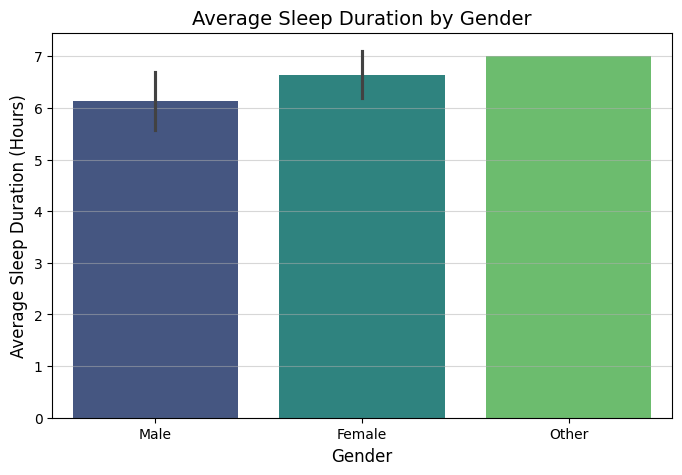

In [ ]:
# Comparison bar plot: Average Sleep Duration by Gender
plt.figure(figsize=(8, 5))
# Get unique genders and assign a color from the viridis palette
gender_order = df_final['Gender'].unique()
gender_colors = sns.color_palette('viridis', len(gender_order))
color_map = dict(zip(gender_order, gender_colors))

sns.barplot(data=df_final, x='Gender', y='On average, how many hours of sleep do you get per night?', hue='Gender', palette=color_map, legend=False)
plt.title('Average Sleep Duration by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Sleep Duration (Hours)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

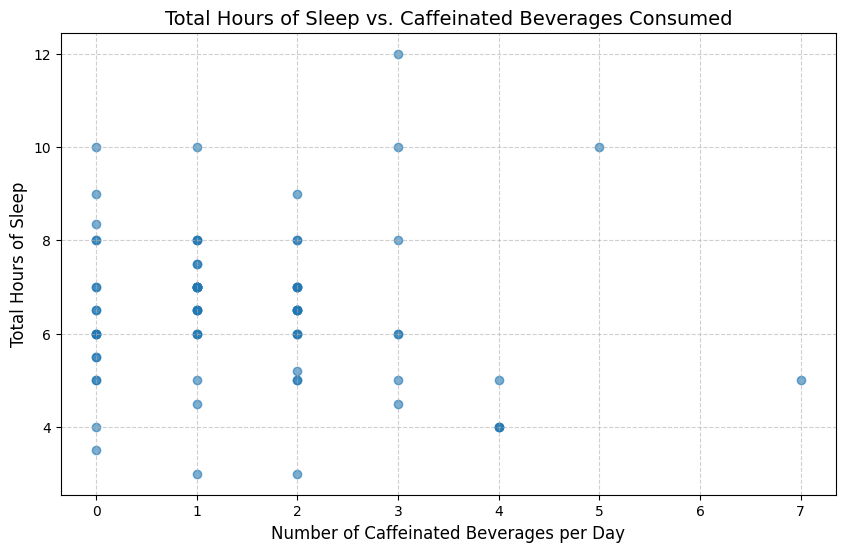

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: Total Hours of Sleep vs. Number of Caffeinated Beverages Consumed
plt.figure(figsize=(10, 6))
plt.scatter(df_final['How many caffeinated beverages (e.g., coffee, tea, energy drinks) do you consume per day, on average?'],
            df_final['On average, how many hours of sleep do you get per night?'],
            alpha=0.6)
plt.title('Total Hours of Sleep vs. Caffeinated Beverages Consumed', fontsize=14)
plt.xlabel('Number of Caffeinated Beverages per Day', fontsize=12)
plt.ylabel('Total Hours of Sleep', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipython-input-1346967144.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep_Hours_Total'].fillna(df['Sleep_Hours_Total'].median(), inplace=True)
/tmp/ipython-input-1346967144.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

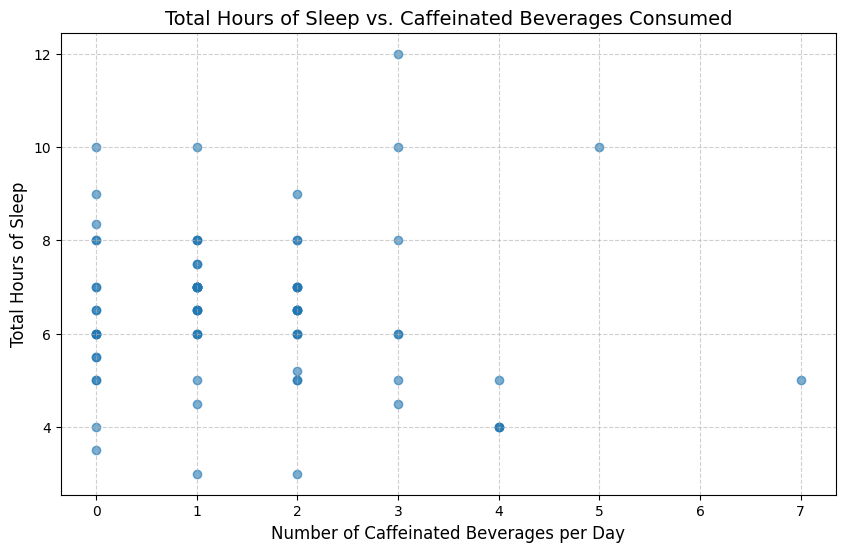

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys # Import sys for sys.exit()

# --- 1. CLEANING AND PREPARATION FUNCTIONS (Robust) ---

def clean_column_names(df):
    """Standardizes column names to snake_case for easy access."""
    cols = df.columns.tolist()
    new_cols = {}
    for col in cols:
        # Aggressive cleaning: lower, strip punctuation/spaces, replace with underscore
        new_name = col.lower().strip().replace('?', '').replace('\n', ' ').replace(':', '').replace('-', ' ').replace('/', '_').replace('.', ' ')
        new_name = '_'.join(new_name.split()).strip('_')
        new_cols[col] = new_name
    df.rename(columns=new_cols, inplace=True)
    return df

def time_to_hours_duration(time_str):
    """Converts a duration string (HH:MM:SS) to total decimal hours."""
    if pd.isna(time_str): return np.nan
    try:
        parts = str(time_str).strip().split(':')
        hours = int(parts[0])
        minutes = int(parts[1]) if len(parts) > 1 else 0
        seconds = int(parts[2]) if len(parts) > 2 else 0
        return hours + (minutes / 60) + (seconds / 3600)
    except Exception: return np.nan

def clean_data_for_graphs(df):
    """Applies necessary cleaning and creates derived columns for graphing."""
    # Clean column names first
    df = clean_column_names(df)

    # Define Column Names mapping from cleaned names to desired names
    df_map = {
        'on_average,_how_many_hours_of_sleep_do_you_get_per_night': 'Sleep_Hours_Total',
        'how_long_does_it_typically_take_you_to_fall_asleep': 'Time_To_Fall_Asleep_Hours',
        # Add the mapping for the caffeine column
        'how_many_caffeinated_beverages_(e_g_,_coffee,_tea,_energy_drinks)_do_you_consume_per_day,_on_average': 'Caffeinated_Beverages_Per_Day'
    }
    # Rename columns using the mapping
    df.rename(columns=df_map, inplace=True)


    # Convert Time to Numerical Hours
    df['Sleep_Hours_Total'] = df['Sleep_Hours_Total'].apply(time_to_hours_duration)
    df['Time_To_Fall_Asleep_Hours'] = df['Time_To_Fall_Asleep_Hours'].apply(time_to_hours_duration)

    # Impute missing values with the median for stable plotting
    df['Sleep_Hours_Total'].fillna(df['Sleep_Hours_Total'].median(), inplace=True)
    df['Time_To_Fall_Asleep_Hours'].fillna(df['Time_To_Fall_Asleep_Hours'].median(), inplace=True)

    return df


# Load and clean the data again within this cell's scope
FILE_PATH = "/content/drive/MyDrive/Untitled form (Responses).xlsx"
try:
    df_final = clean_data_for_graphs(pd.read_excel(FILE_PATH))
except FileNotFoundError:
    print(f"Error: File not found at path: {FILE_PATH}. Please ensure the file is accessible.")
    # You might want to add a more robust error handling or exit strategy here
    df_final = pd.DataFrame() # Create an empty DataFrame to avoid further errors if file not found


# Scatter plot: Total Hours of Sleep vs. Number of Caffeinated Beverages Consumed
if not df_final.empty:
    plt.figure(figsize=(10, 6))
    plt.scatter(df_final['Caffeinated_Beverages_Per_Day'], # Use the cleaned column name
                df_final['Sleep_Hours_Total'], # Use the cleaned column name
                alpha=0.6)
    plt.title('Total Hours of Sleep vs. Caffeinated Beverages Consumed', fontsize=14)
    plt.xlabel('Number of Caffeinated Beverages per Day', fontsize=12)
    plt.ylabel('Total Hours of Sleep', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("DataFrame is empty after loading or cleaning. Cannot generate plot.")